# **Notebook 11 – Dimensionality Reduction**

In [2]:
# Load Datset
import pandas as pd
df = pd.read_csv("customer_health_lifestyle_dataset.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Customer_ID          2000 non-null   object 
 1   Age                  2000 non-null   int64  
 2   Height_cm            2000 non-null   float64
 3   Weight_kg            2000 non-null   float64
 4   BMI                  1992 non-null   float64
 5   Daily_Steps          2000 non-null   int64  
 6   Sleep_Hours          1994 non-null   float64
 7   Exercise_Hours       2000 non-null   float64
 8   Heart_Rate           2000 non-null   int64  
 9   Blood_Pressure       2000 non-null   int64  
 10  Calories_Intake      2000 non-null   int64  
 11  Water_Intake_L       1995 non-null   float64
 12  Stress_Level         2000 non-null   int64  
 13  Resting_Heart_Rate   2000 non-null   int64  
 14  Active_Minutes       2000 non-null   int64  
 15  Screen_Time_Hours    2000 non-null   f

## **1. What is Dimensionality?**

**Understand the Concept**

* Dimensionality means the number of features in a dataset.
* More features mean higher dimensionality.

**Demonstrate the Concept**

* Our dataset has many features - Age, BMI, Daily_Steps, and Sleep_Hours.
* Each feature adds one dimension to the data.

In [3]:
print("Number of features:", df.shape[1])

Number of features: 19


**Explanation**

* shape shows the number of rows and columns.
* Columns represent the dimensions of the dataset.



## **2. High-Dimensional Data**

**Understand the Concept**

* High-dimensional data has a large number of features.
* More features can make the data harder to understand and process.

## **3. Curse of Dimensionality**

**Understand the Concept**

* The curse of dimensionality happens when a dataset has too many features.
* Too many features can make the model slower and less effective.
* More features can make the data harder for a model to learn.

## **4. Why Reduce Dimensions?**

**Understand the Concept**

* Dimensionality reduction means reducing the number of features.
* It keeps the important information while making the data simpler.
* PCA can reduce these features into fewer components.

## **5. PCA**

**Understand the Concept**

* PCA reduces many features into fewer new features called components.
* It tries to keep the most important information.

**Demonstrate the Concept**

* PCA takes many features like Age, BMI, and Daily_Steps.
* It combines their information into fewer components.

In [5]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X = df.select_dtypes(include="number")

X = X.fillna(X.median())

X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
print(X_pca.shape)

(2000, 2)


**Explanation**

* The features are scaled before PCA.
* PCA reduces the features to 2 components.

**Justify Your Feature**

* I used PCA to reduce many features into two components for easier analysis and visualization.

## **6. Principal Components**

**Understand the Concept**

* Principal Components are new features created by PCA.
* They contain the important information from the original features.

**Demonstrate the Concept**

* PCA changes many original features into fewer components.
* PC1 contains the most important information, followed by PC2.

In [6]:
print("PC1:", pca.components_[0])
print("PC2:", pca.components_[1])

PC1: [ 0.03330714 -0.36176352  0.59766161  0.69698262  0.01683916  0.04737984
 -0.0263427  -0.00660103  0.03875773  0.02845428 -0.03057057 -0.00617974
  0.0480116  -0.01796746  0.12591741]
PC2: [ 0.13791912  0.43362357  0.31800647  0.05809223 -0.20781485 -0.24273561
  0.24114015  0.4392724  -0.32687129 -0.1219443  -0.15527196 -0.13173065
 -0.15807218  0.29721645 -0.24233794]


**Explanation**

* PC1 and PC2 are the new features created by PCA.
* They are combinations of the original features.



## **7. Explained Variance**

**Understand the Concept**

* Explained variance shows how much information each component keeps.
* Higher variance means the component keeps more information.

**Demonstrate the Concept**

* PC1 usually keeps more information than PC2.
* We can check how much information both components keep.

In [7]:
print("Explained Variance:", pca.explained_variance_ratio_)
print("Total Variance:", pca.explained_variance_ratio_.sum())

Explained Variance: [0.13471801 0.07528493]
Total Variance: 0.2100029392498095


**Explanation**

* The scores show the information kept by each component.
* The total shows how much information the selected components keep.

**Justify Your Feature**

* I checked explained variance to see how much information is retained after PCA.

## **8. Eigenvectors**

**Understand the Concept**

* Eigenvectors show the direction of each principal component.
* They show how the original features contribute to the components.
* PCA uses these directions to create new features called Principal Components.
* A large positive or negative value means that feature has a stronger contribution.

**Demonstrate the Concept**

* PCA uses eigenvectors to create new directions.
* These directions are used to form the principal components.

In [8]:
print("Eigenvectors:")
print(pca.components_)

Eigenvectors:
[[ 0.03330714 -0.36176352  0.59766161  0.69698262  0.01683916  0.04737984
  -0.0263427  -0.00660103  0.03875773  0.02845428 -0.03057057 -0.00617974
   0.0480116  -0.01796746  0.12591741]
 [ 0.13791912  0.43362357  0.31800647  0.05809223 -0.20781485 -0.24273561
   0.24114015  0.4392724  -0.32687129 -0.1219443  -0.15527196 -0.13173065
  -0.15807218  0.29721645 -0.24233794]]


**Explanation**

* The values show how each feature contributes to each component.
* These values help us understand the direction of the components.



## **9. Eigenvalues**

**Understand the Concept**

* Eigenvalues show how much information each Principal Component contains.
* A higher eigenvalue means the component contains more information.

**Demonstrate the Concept**

* PC1 may have the highest eigenvalue.
* PC2 may have a smaller eigenvalue.
* So, PC1 explains more variation in the data.

In [9]:
print("Eigenvalues:")
print(pca.explained_variance_)

Eigenvalues:
[2.02178106 1.12983884]


**Explanation**

* The values show the variance captured by each component.
* Higher values mean more variation is captured.
\

## **10. PCA Transformation**

**Understand the Concept**

* PCA transforms the original features into new Principal Components.
* It reduces many features into fewer components.

**Demonstrate the Concept**

* Original data has many features.
* PCA transforms them into PC1 and PC2.

In [13]:
X_pca = pca.transform(X_scaled)
print(X_pca)

[[ 2.16223278  0.18460676]
 [-0.65555474 -0.99191571]
 [ 1.29041677 -0.2180961 ]
 ...
 [-2.70740231 -0.3638186 ]
 [ 0.39255365 -2.09791545]
 [ 0.73466134 -0.33112659]]


**Explanation**

* The original features are converted into PCA components.
* Each row now contains PC1 and PC2 values.



## **11. PCA Visualization**

**Understand the Concept**

* PCA visualization helps us see the data in fewer dimensions.
* We can use PC1 and PC2 to create a 2D plot.

**Demonstrate the Concept**

* Each point represents one customer.
* PC1 and PC2 are shown on the graph.

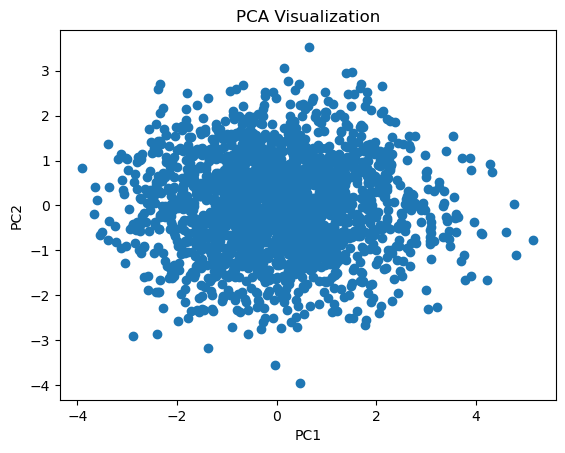

In [14]:
import matplotlib.pyplot as plt

plt.scatter(X_pca[:, 0], X_pca[:, 1])
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Visualization")
plt.show()

**Explanation**

* The graph shows customers using two PCA components.
* It helps us see patterns in the data.


## **12. Advantages of PCA**



* Reduces the number of features.
* Makes data easier to visualize.
* Can reduce unnecessary information.
* Can make model training faster.

## **13. Limitations of PCA**



* PCA can make features difficult to understand.
* It may lose some information.
* PCA works best with numerical data.
* Scaling is usually needed before PCA.

## **14. When to Use PCA**



* Use PCA when there are many numerical features.
* Use it when you want to reduce the number of features.
* Use it when you want to visualize high-dimensional data.



## **15. When Not to Use PCA**

* Avoid PCA when feature meaning is very important.
* Avoid it when the dataset has very few features.
* PCA is not suitable for directly handling categorical features.


## **16. Complete PCA Example**

**Understand the Concept**

* We scale the data and then apply PCA.
* PCA reduces the original features into fewer components.

**Demonstrate the Concept**

* Our dataset has many numerical features.
* We reduce them to 2 components for analysis and visualization.

In [15]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [17]:
# Select numerical features
X = df.select_dtypes(include="number")

In [18]:
# Fill missing values
X = X.fillna(X.median())

In [19]:
# Scale the features
X_scaled = StandardScaler().fit_transform(X)

In [20]:
# Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Original features:", X.shape[1])
print("PCA components:", X_pca.shape[1])
print("Explained variance:", pca.explained_variance_ratio_)

Original features: 15
PCA components: 2
Explained variance: [0.13471801 0.07528493]


**Explanation**

* The data is cleaned and scaled first.
* PCA reduces the features to 2 components.
* Explained variance shows how much information is kept.
